# Gradio Binary Mask Segmentation Demo
* Author: Juan Pablo Triana Martinez
* Date: 2026-04-18

This notebook is a step by step process in order to create in `gradio`, a live demo!


### Note
**This implies trained models have already being performed, therefore it's important to clarify that a trained `.pth` model has already being setup before hand**

The following Demo will be able to do the following:
1. Add an input image, *Preferably an image of a document*.
2. Transform the image in such a way that can be used by the `.pth` model.
3. IF ground truth mask are passed, then allow masks to be used for IoU and DsCs calculations, otherwise don't use them and return `Hard and Soft IoU and DsC metrics are unavailable`
4. Overlap the `predicted_mask` on top of the `image`

Without further do, let's do this!

## 1. Read a specific dataset


In [59]:
from pathlib import Path
import sys
import torch
from torchvision import transforms
from typing import Dict

In [60]:
# Resolve the project root and add it to the module search path
working_path = Path().cwd().parent
sys.path.insert(0, str(working_path))

In [61]:
DATA_PATH = working_path / "data"
SUBSET_DATANAME= "doclaynet_20_percent_seed_7"

# Let's define the transforms to avoid so much time wasted for calculating std and mean per channel
# NOTE: Mimicking the same transform when trained

# Found empirically from 20% of the dataset
mean = [0.9329, 0.9343, 0.9341]
std = [0.1651, 0.1592, 0.1623]
new_height = 512
new_width = 512

# This is used for inference
inference_transform = transforms.Compose([
    transforms.Resize((new_height, new_width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    ])

## 2. Let's load a binary model

In [62]:
from src.models import LinknetModel

In [63]:
# Let's retrieeve the models path
MODEL_NAME = "linknet_binary_doclaynet_20_percent_seed_7_ce_0.25_dice_1.0_.pth"
model_path = Path().cwd().parent / "models" / MODEL_NAME
model_path.exists()

True

In [64]:
# Force the device to be cpu, since this will be the environment running
# in huggingface
device = "cpu" 
binary_text_model = LinknetModel(Cin=3, N=1).to(device)

In [65]:
# Let's load the trained google collab model
binary_text_model.load_state_dict(torch.load(f = model_path, map_location=device))

<All keys matched successfully>

### 3. Let's retrieve a random image
we will be getting random images from the specific `SUBSET_DATANAME` as examples to perform predictions on single images.

We will be simulating two cases:
1. One where we do have the ground truth masks, for this we will be using the `TextDetectionDataset` to obtain the binary ground truth masks and use that to create the gradio demo.
2. One where we only have a random image, without a ground truth mask

In [66]:
from src.data import TextDetectionDataset

In [67]:
text_detection_dataset = TextDetectionDataset(data_path = DATA_PATH,
                split_analyze = "test",
                dataset_name = SUBSET_DATANAME,
                mask_type = "binary-text",
                new_height = new_height,
                new_width = new_width,
                transform= None)

In [68]:
test_img, test_mask, test_img_metadata = text_detection_dataset[52]
print(f"Image input shape: {test_img.shape}")
print(f"Semantic layout shape: {test_mask.shape}, dtype: {test_mask.dtype}")
print(f"Image metadata: {test_img_metadata}")

Image input shape: torch.Size([3, 512, 512])
Semantic layout shape: torch.Size([1, 512, 512]), dtype: torch.float32
Image metadata: {'id': 5238, 'width': 512, 'height': 512, 'file_name': 'e88eae40543079878d634329b442674bdbb573f34838188e4b472aaa884f07bf.png', 'collection': 'redbooks', 'doc_name': 'sg247938.pdf', 'page_no': 285, 'precedence': 0, 'doc_category': 'manuals'}


{'id': 5238, 'width': 512, 'height': 512, 'file_name': 'e88eae40543079878d634329b442674bdbb573f34838188e4b472aaa884f07bf.png', 'collection': 'redbooks', 'doc_name': 'sg247938.pdf', 'page_no': 285, 'precedence': 0, 'doc_category': 'manuals'}


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

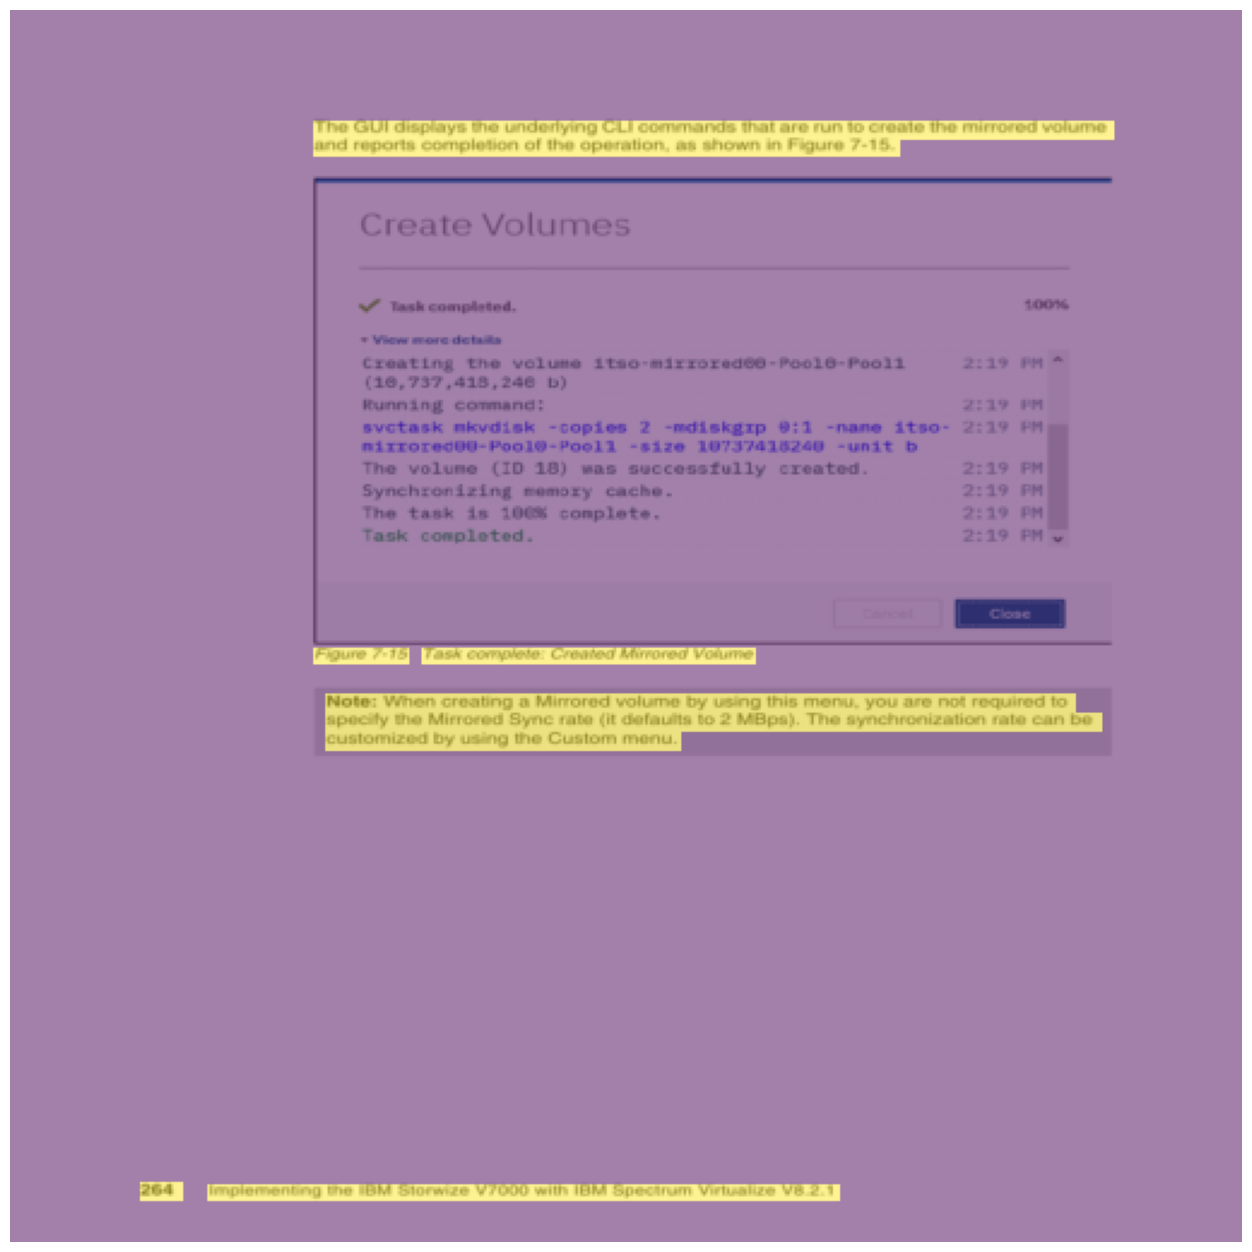

In [69]:
import matplotlib.pyplot as plt
print(test_img_metadata)
img = test_img.permute(1, 2, 0).cpu()
mask = test_mask.permute(1, 2, 0).cpu()

plt.figure(figsize=(16, 16))
plt.imshow(img)
plt.imshow(mask, alpha=0.5,)  # alpha controls transparency
plt.axis("off")

In [70]:
import os
import numpy as np
from PIL import Image

def save_img_and_mask_separately(
        img_tensor: torch.Tensor,
        mask_tensor: torch.Tensor,
        save_dir: Path,
        filename: str):
    """
    Saves image and mask separately as PNG files.

    Args:
        img_tensor (torch.Tensor): Shape [C, H, W]
        mask_tensor (torch.Tensor): Shape [C, H, W] or [1, H, W]
        save_dir (str): Directory to save files
        filename (str): Base filename (no extension)
    """

    save_dir.mkdir(parents = True, exist_ok=True)

    # Convert to numpy (H, W, C)
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    mask = mask_tensor.permute(1, 2, 0).cpu().numpy()

    # Handle single-channel mask
    if mask.shape[-1] == 1:
        mask = mask.squeeze(-1)

    # Normalize if needed
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    if mask.max() <= 1.0:
        mask = (mask * 255).astype(np.uint8)
    else:
        mask = mask.astype(np.uint8)

    # Convert to PIL Images
    img_pil = Image.fromarray(img)
    mask_pil = Image.fromarray(mask)

    # Save paths
    img_path = os.path.join(save_dir, f"{filename}_img.png")
    mask_path = os.path.join(save_dir, f"{filename}_mask.png")

    img_pil.save(img_path)
    mask_pil.save(mask_path)

    return img_path, mask_path

In [71]:
### Let's save a couple of images inside a folder called demo
save_dir_demo = Path().cwd().parent / "demo"
img_path_saved, mask_path_saved = save_img_and_mask_separately(img_tensor=test_img,
                                                               mask_tensor=test_mask,
                                                               save_dir=save_dir_demo,
                                                               filename="binary_3")

[INFO] Prediction on image at path: [WindowsPath('c:/Users/ajedr/Documents/Masters_Post_Cert_AI_Stanford_USD_2023_2026/AAI_590_Machine_Learning_Capstone/AAI-590-OCR-Master/data/doclaynet_20_percent_seed_7/PNG/688b0a4b5f8ef039ccbb5801409017f72b221cf25242e0c475fea703c2226406.png')]


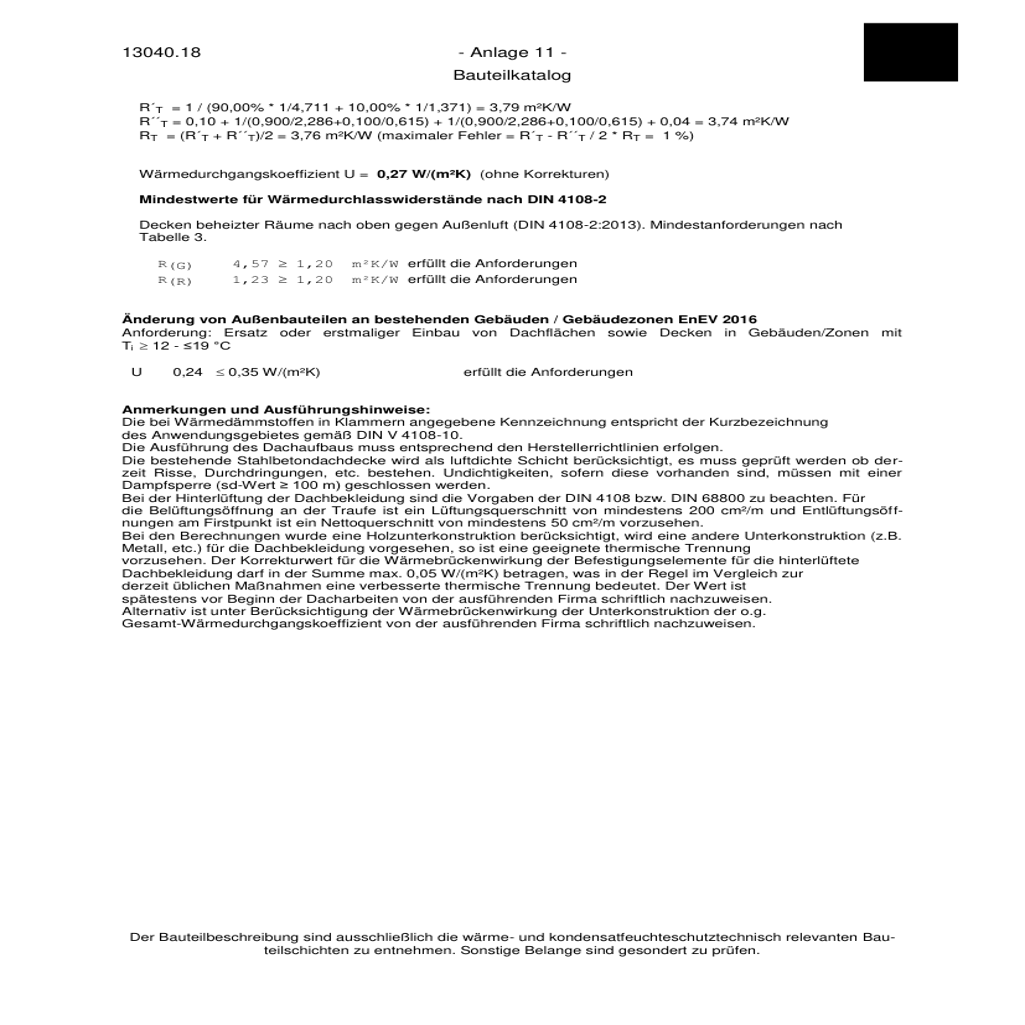

In [72]:
import random
from PIL import Image

# Get a list of all images and get any
png_path = DATA_PATH / SUBSET_DATANAME / "PNG"
all_data_paths  = list(png_path.glob("*.png"))

random_image_path = random.sample(all_data_paths, k=1)
# Open the target image
image = Image.open(random_image_path[0])
print(f"[INFO] Prediction on image at path: {random_image_path}")
image

In [73]:
import torchvision
from typing import Tuple, Dict
from PIL import Image
from src.utils import get_binary_metrics, get_soft_metrics, logits_to_binary_mask

def predict(img:Image) -> Tuple[Dict, float]:
    
    # Let's setup the model to eval
    binary_text_model.eval()

    # Let's tranform the image
    img = inference_transform(img).unsqueeze(0) # Add a batch dimension for inference

    # Let's use torch.inference_mode() to not keep gradients
    with torch.inference_mode():
        # Get the logits of the model 
        img_logits = binary_text_model(img)

        # Get the img mask
        img_mask = logits_to_binary_mask(img_logits, threshold=0.5)
    
    return img_logits, img_mask


In [74]:
img_logits, img_mask = predict(img = image)

In [75]:
import gradio as gr
import torch
import numpy as np
from collections import defaultdict

# Load model
model = binary_text_model
model.eval()

api_transform = transforms.Compose([
    transforms.Resize((new_height, new_width)),
    transforms.ToTensor()])

def preprocess(image):
    # Let's tranform the image
    trans_image = inference_transform(image).unsqueeze(0) # Add a batch dimension for inference
    return trans_image

def predict_mask(image):
    with torch.inference_mode():
        # Get the logits of the model 
        image_logits = binary_text_model(image)

        # Get the img mask
        img_mask = logits_to_binary_mask(image_logits, threshold=0.5)
    return image_logits, img_mask

def overlay_mask(image, mask):
    """
    image: torch.Tensor (1, 3, H, W)
    mask:  torch.Tensor (1, 1, H, W)
    returns: numpy array (H, W, 3)
    """

    # Add a copy to not modify original image
    image = image.clone()
    mask = mask.clone()

    # Remove batch dimension
    image = image.squeeze(0)   # (3, H, W)
    mask = mask.squeeze(0)     # (1, H, W)

    # Ensure on CPU
    image = image.detach().cpu()
    mask = mask.detach().cpu()

    # Normalize image if needed (assumes [0,1])
    image = image.clone()

    # Expand mask to 3 channels
    mask = mask.repeat(3, 1, 1)  # (3, H, W)

    # Create overlay (green channel boost)
    overlay = image.clone()
    overlay[1] = torch.maximum(overlay[1], mask[1])  # channel 1 = green

    # Convert to numpy HWC
    overlay = overlay.permute(1, 2, 0).numpy()

    return overlay

def inference(image, gt_mask=None):
    trans_image = preprocess(image)
    image_logits, pred_mask = predict_mask(trans_image)

    overlay = overlay_mask(api_transform(img=image), pred_mask)
    overlay = (overlay * 255).clip(0, 255).astype(np.uint8)

    pred_mask_np = pred_mask.squeeze().cpu().numpy()  # (H, W)

    if gt_mask is None:
        # Squeeze at batch dimension -> permute from C* H * W to H * W * C -> cast to numpy
        return pred_mask_np, overlay, "No ground truth provided → metrics unavailable"

    gt_tensor = api_transform(gt_mask.convert("L")).unsqueeze(0)
    print(gt_tensor.shape)

    # Get hard and soft IoUs and DsCs
    print(f"Predicted mask shape: {pred_mask.shape}")
    print(f"Ground truth mask shape: {gt_tensor.shape}")
    hard_metrics = get_binary_metrics(pred_mask, gt_tensor)
    soft_metrics = get_soft_metrics(pred_mask, gt_tensor, is_binary=True)

    # Let's now define the total_metrics dictionary
    total_metrics: Dict[str, list] = defaultdict(list)

    # Append all the soft and hard pixel metrics
    for k, v in hard_metrics.items():
        total_metrics[k].append(float(v))
    for k, v in soft_metrics.items():
        total_metrics[k].append(float(v.mean()))

    return pred_mask_np, overlay, total_metrics

EXAMPLES_DIR = working_path / "examples"

demo = gr.Interface(
    fn=inference,
    inputs=[
        gr.Image(type="pil", label="Input Image"),
        gr.Image(type="pil", label="Ground Truth Mask"),
    ],
    outputs=[
        gr.Image(label="Predicted Mask"),
        gr.Image(label="Overlay"),
        gr.Textbox(label="Metrics"),
    ],
    title="LinkNet Binary Text Segmentation ChestNut 🌰",
    description=(
        "Upload a document image to obtain its binary text segmentation mask. "
        "Optionally upload a ground-truth binary mask to compute hard pixel metrics "
        "(accuracy, precision, recall, F1, IoU, Dice) and soft region metrics (IoU, DsC)."
    ),
    examples=[
        [str(EXAMPLES_DIR / "binary_1_img.png"), str(EXAMPLES_DIR / "binary_1_mask.png")],
        [str(EXAMPLES_DIR / "binary_2_img.png"), str(EXAMPLES_DIR / "binary_2_mask.png")],
        [str(EXAMPLES_DIR / "binary_3_img.png"), str(EXAMPLES_DIR / "binary_3_mask.png")],
    ]
)

demo.launch(debug=False, share=True, allowed_paths = [str(EXAMPLES_DIR)])

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://8f1ed23aa4be34de41.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


torch.Size([1, 1, 512, 512])
Predicted mask shape: torch.Size([1, 1, 512, 512])
Ground truth mask shape: torch.Size([1, 1, 512, 512])
